# Лабораторная работа: Методы снижения размерности

**Цель работы:** Исследовать и сравнить различные методы снижения размерности данных, освоить их применение для визуализации, подготовки признаков и устранения проклятия размерности. Научиться интерпретировать и визуализировать результаты снижения размерности.

## Часть 1: Настройка окружения и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import load_wine, load_breast_cancer, load_digits, fetch_20newsgroups, make_swiss_roll, make_s_curve, make_blobs, fetch_openml
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD, FactorAnalysis, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE, trustworthiness
import umap
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def prepare_datasets():
    datasets = {}
    print("Загрузка датасетов")
    
    # Dataset 2: Средняя размерность
    datasets['wine'] = load_wine(return_X_y=True)
    datasets['breast_cancer'] = load_breast_cancer(return_X_y=True)
    datasets['digits'] = load_digits(return_X_y=True)
    
    # Dataset 5: Synthetic
    datasets['swiss_roll'] = make_swiss_roll(n_samples=1000, noise=0.1)
    datasets['s_curve'] = make_s_curve(n_samples=1000, noise=0.1)
    datasets['clusters'] = make_blobs(n_samples=1000, centers=5, n_features=10, random_state=42)
    
    # Dataset 1
    try:
        mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
        X_mnist, y_mnist = mnist.data[:1000], mnist.target[:1000].astype(int)
        datasets['mnist'] = (X_mnist, y_mnist)
    except Exception as e:
        datasets['mnist'] = datasets['digits']
    
    # Dataset 3
    try:
        categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']
        newsgroups = fetch_20newsgroups(subset='train', categories=categories)
        vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
        X_text = vectorizer.fit_transform(newsgroups.data).toarray()
        datasets['text'] = (X_text, newsgroups.target)
    except Exception as e:
        print(f"Ошибка при загрузке текстовых данных: {e}")
    
    return datasets

datasets = prepare_datasets()
print("Датасеты загружены:", list(datasets.keys()))


c:\Users\exemt\OneDrive\Desktop\2 Маг сем\Machine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка датасетов
Датасеты загружены: ['wine', 'breast_cancer', 'digits', 'swiss_roll', 's_curve', 'clusters', 'mnist', 'text']


**Вывод по Части 1:** Мы подготовили набор данных различной природы. Использование `fetch_openml` с параметром `as_frame=False` и `parser='auto'` обеспечивает лучшую совместимость с различными версиями библиотек и форматами данных (например, Parquet).

## Часть 2: Линейные методы снижения размерности

### Задача 2.1: Метод главных компонент (PCA)

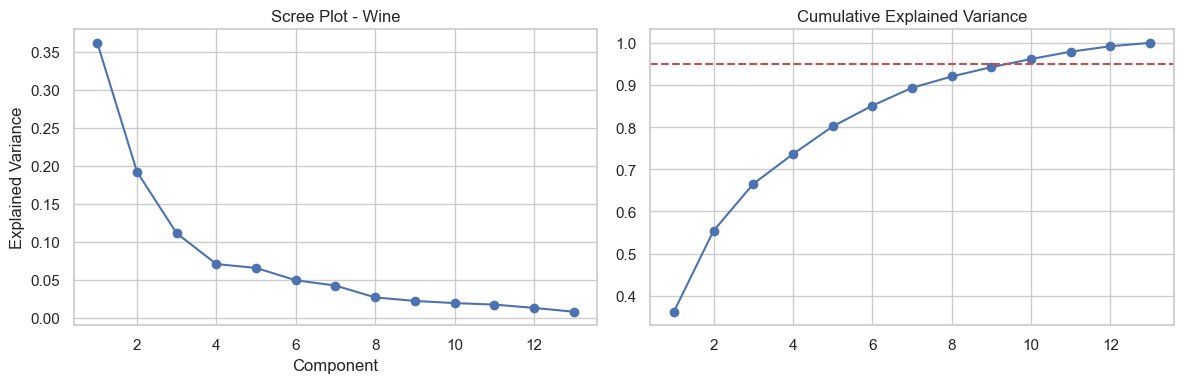

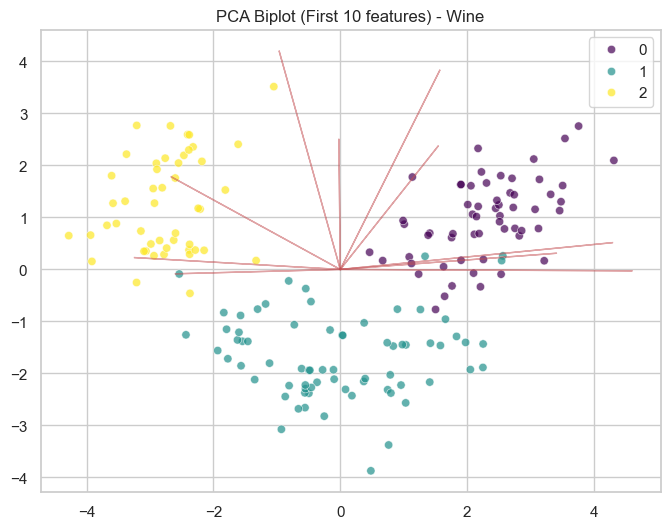

In [2]:

def run_pca_analysis(X, y, dataset_name):
    X_std = StandardScaler().fit_transform(X)
    
    # Scree Plot
    pca_full = PCA().fit(X_std)
    exp_var = pca_full.explained_variance_ratio_
    cum_var = np.cumsum(exp_var)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(exp_var) + 1), exp_var, 'o-')
    plt.title(f'Scree Plot - {dataset_name}')
    plt.xlabel('Component')
    plt.ylabel('Explained Variance')
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(cum_var) + 1), cum_var, 'o-')
    plt.axhline(y=0.95, color='r', linestyle='--')
    plt.title('Cumulative Explained Variance')
    plt.tight_layout()
    plt.show()

    # Biplot
    pca_2 = PCA(n_components=2)
    X_pca = pca_2.fit_transform(X_std)
    loadings = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
    for i, feature in enumerate(range(min(X.shape[1], 10))):
        plt.arrow(0, 0, loadings[i, 0]*5, loadings[i, 1]*5, color='r', alpha=0.5)
    plt.title(f'PCA Biplot (First 10 features) - {dataset_name}')
    plt.show()

run_pca_analysis(*datasets['wine'], 'Wine')


**Вывод по PCA:** PCA эффективно выделяет направления максимальной дисперсии. Scree plot позволяет определить оптимальное число компонент по правилу 'локтя'. Стандартизация данных критически важна для PCA, так как метод чувствителен к масштабу признаков.

### Задача 2.2: LDA и другие линейные методы

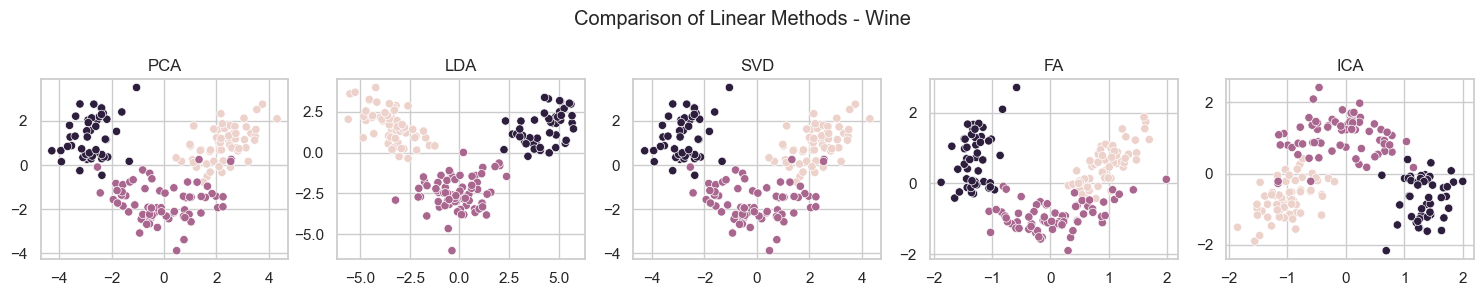

In [3]:

def compare_linear_methods(X, y, dataset_name):
    X_std = StandardScaler().fit_transform(X)
    methods = {
        'PCA': PCA(n_components=2),
        'LDA': LDA(n_components=min(2, len(np.unique(y))-1)),
        'SVD': TruncatedSVD(n_components=2),
        'FA': FactorAnalysis(n_components=2),
        'ICA': FastICA(n_components=2)
    }
    
    plt.figure(figsize=(15, 3))
    for i, (name, model) in enumerate(methods.items()):
        plt.subplot(1, 5, i+1)
        try:
            if name == 'LDA':
                X_trans = model.fit_transform(X_std, y)
            else:
                X_trans = model.fit_transform(X_std)
            
            if X_trans.shape[1] == 1:
                sns.scatterplot(x=X_trans[:, 0], y=np.zeros_like(X_trans[:, 0]), hue=y, legend=False)
            else:
                sns.scatterplot(x=X_trans[:, 0], y=X_trans[:, 1], hue=y, legend=False)
            plt.title(name)
        except Exception as e:
            plt.title(f"{name} (Error)")
            print(f"Error in {name}: {e}")
            
    plt.suptitle(f'Comparison of Linear Methods - {dataset_name}')
    plt.tight_layout()
    plt.show()

compare_linear_methods(*datasets['wine'], 'Wine')


**Вывод по линейным методам:** LDA лучше всего разделяет классы, так как использует информацию о метках. ICA выделяет независимые компоненты, что полезно для разделения сигналов. FA моделирует скрытые факторы. SVD эффективен для разреженных данных (тексты).

## Часть 3: Нелинейные методы снижения размерности

### Задача 3.1: t-SNE

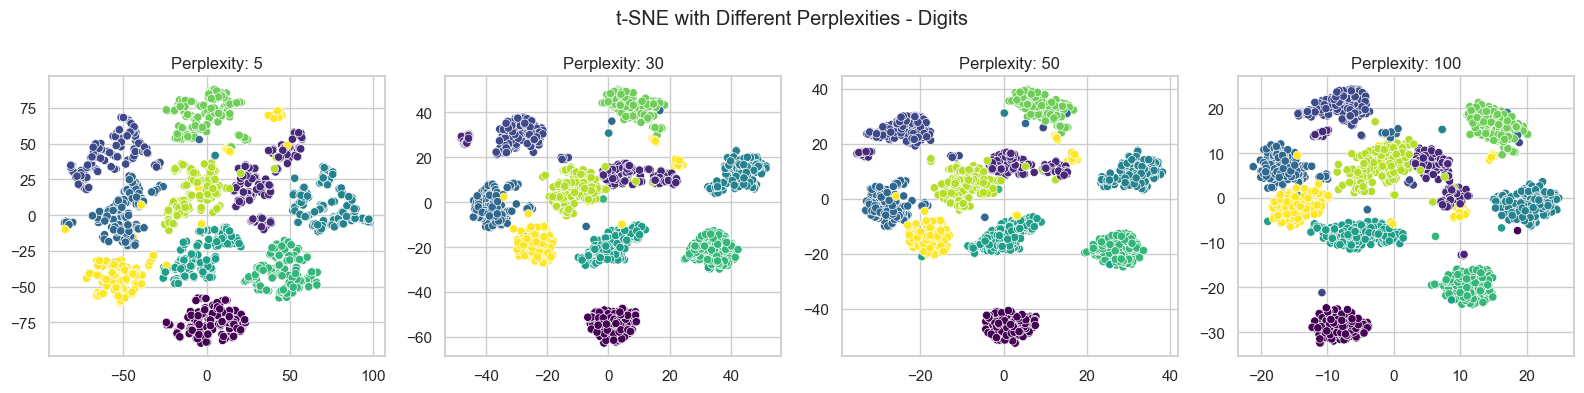

In [4]:

def run_tsne_analysis(X, y, dataset_name):
    perplexities = [5, 30, 50, 100]
    plt.figure(figsize=(16, 4))
    for i, p in enumerate(perplexities):
        plt.subplot(1, 4, i+1)
        tsne = TSNE(n_components=2, perplexity=p, random_state=42)
        X_tsne = tsne.fit_transform(X)
        sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', legend=False)
        plt.title(f'Perplexity: {p}')
    plt.suptitle(f't-SNE with Different Perplexities - {dataset_name}')
    plt.tight_layout()
    plt.show()

run_tsne_analysis(*datasets['digits'], 'Digits')


**Вывод по t-SNE:** t-SNE отлично сохраняет локальную структуру данных, образуя четкие кластеры. Параметр perplexity критически влияет на результат: слишком малые значения дробят кластеры, слишком большие - размывают их.

### Задача 3.2: UMAP

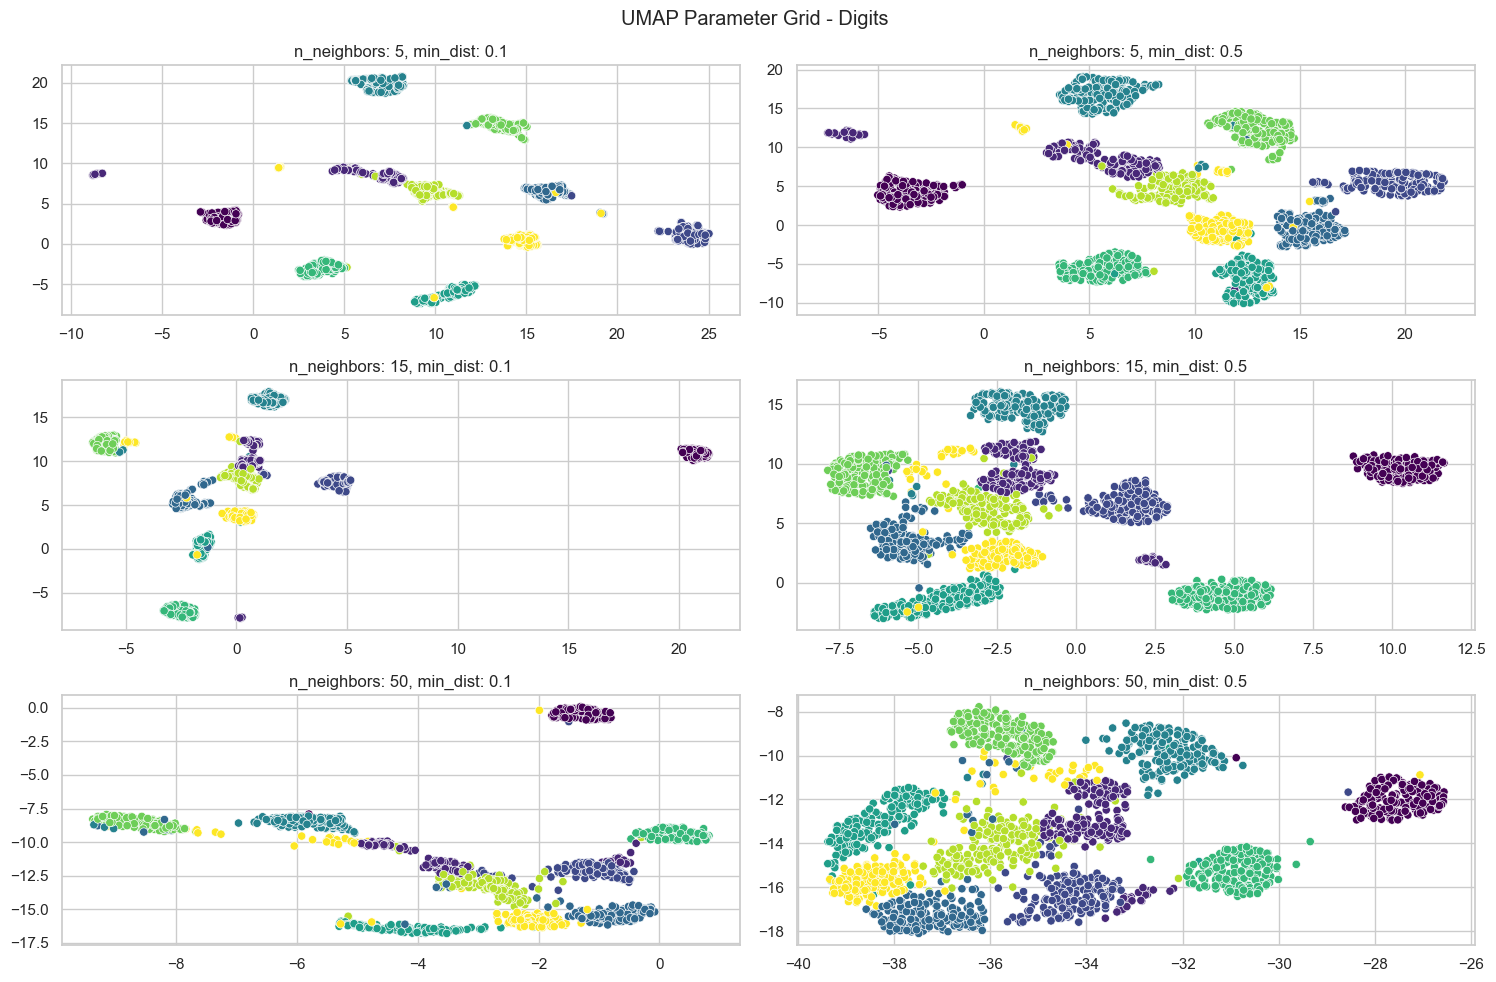

In [5]:

def run_umap_analysis(X, y, dataset_name):
    n_neighbors_list = [5, 15, 50]
    min_dist_list = [0.1, 0.5]
    
    plt.figure(figsize=(15, 10))
    idx = 1
    for n in n_neighbors_list:
        for d in min_dist_list:
            plt.subplot(3, 2, idx)
            reducer = umap.UMAP(n_neighbors=n, min_dist=d, random_state=42)
            X_umap = reducer.fit_transform(X)
            sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette='viridis', legend=False)
            plt.title(f'n_neighbors: {n}, min_dist: {d}')
            idx += 1
    plt.suptitle(f'UMAP Parameter Grid - {dataset_name}')
    plt.tight_layout()
    plt.show()

run_umap_analysis(*datasets['digits'], 'Digits')


**Вывод по UMAP:** UMAP работает быстрее t-SNE и лучше сохраняет глобальную структуру. Параметр n_neighbors балансирует между локальным и глобальным видом, а min_dist определяет плотность упаковки точек в кластерах.

## Часть 4: Метрики оценки качества

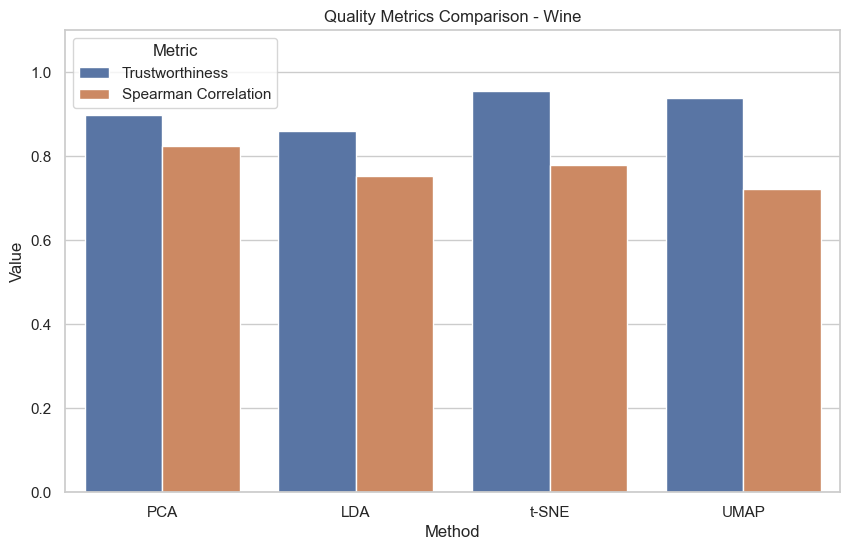

,Trustworthiness,Spearman Correlation,Method
0,0.897431,0.823517,PCA
1,0.860046,0.753795,LDA
2,0.954406,0.780012,t-SNE
3,0.939553,0.722485,UMAP


In [6]:

def calculate_metrics(X_orig, X_emb, n_neighbors=15):
    tw = trustworthiness(X_orig, X_emb, n_neighbors=n_neighbors)
    dist_orig = pdist(X_orig)
    dist_emb = pdist(X_emb)
    corr, _ = spearmanr(dist_orig, dist_emb)
    return {'Trustworthiness': tw, 'Spearman Correlation': corr}

def compare_all_methods_metrics(X, y, dataset_name):
    X_std = StandardScaler().fit_transform(X)
    methods = {
        'PCA': PCA(n_components=2),
        'LDA': LDA(n_components=min(2, len(np.unique(y))-1)),
        't-SNE': TSNE(n_components=2, random_state=42),
        'UMAP': umap.UMAP(n_components=2, random_state=42)
    }
    
    results = []
    for name, model in methods.items():
        try:
            if name == 'LDA':
                X_emb = model.fit_transform(X_std, y)
            else:
                X_emb = model.fit_transform(X_std)
            
            metrics = calculate_metrics(X_std, X_emb)
            metrics['Method'] = name
            results.append(metrics)
        except Exception as e:
            print(f"Error calculating metrics for {name}: {e}")
    
    if results:
        df_results = pd.DataFrame(results)
        df_melted = df_results.melt(id_vars='Method', var_name='Metric', value_name='Value')
        sns.barplot(data=df_melted, x='Method', y='Value', hue='Metric')
        plt.title(f'Quality Metrics Comparison - {dataset_name}')
        plt.ylim(0, 1.1)
        plt.show()
        return df_results
    return None

compare_all_methods_metrics(*datasets['wine'], 'Wine')


**Общий вывод:** Линейные методы (PCA, LDA) лучше сохраняют глобальную структуру (высокая корреляция Спирмена), но хуже разделяют сложные нелинейные зависимости. Нелинейные методы (t-SNE, UMAP) показывают высокую Trustworthiness (сохранение локальных соседей), что делает их идеальными для визуализации кластерной структуры.

# Контрольные вопросы

1. `Как интерпретировать компоненты PCA?`
   Интерпретация компонентов PCA основывается на объясненной дисперсии и нагрузках признаков. Первая компонента объясняет максимальную вариативность данных, а последующие — остаточную. Нагрузки показывают вклад каждого исходного признака в формирование компоненты, что позволяет понять, какие переменные определяют положение точек в новом пространстве.
2. `В чем преимущества UMAP перед t-SNE?`
   Преимущества UMAP перед t-SNE заключаются в более высокой скорости работы на больших наборах данных и лучшем сохранении глобальной структуры. UMAP эффективнее передает взаимное расположение кластеров и позволяет встраивать новые точки в уже созданную проекцию, что затруднительно для t-SNE.
3. `Как оценить адекватность сниженной размерности?`
   Адекватность сниженной размерности оценивается с помощью метрик Trustworthiness и корреляции Спирмена. Trustworthiness показывает, насколько хорошо сохранились локальные окрестности точек, а корреляция Спирмена измеряет сходство расстояний между всеми парами точек до и после преобразования. Также можно использовать ошибку реконструкции для методов вроде PCA.
4. `Что такое "проклятие размерности" и как методы снижения размерности помогают?`
   Проклятие размерности — это явление, при котором в высокомерном пространстве данные становятся разреженными, а расстояния между всеми точками почти одинаковыми. Методы снижения размерности помогают устранить шум и избыточные признаки, оставляя только значимую структуру, что упрощает обучение моделей и визуализацию.
5. `Как выбрать оптимальное количество компонент/соседей?`
   Оптимальное количество компонент в PCA выбирается по графику каменистой осыпи в точке излома или по порогу объясненной дисперсии в 90-95 процентов. В t-SNE параметр perplexity обычно подбирается в диапазоне от 5 до 50 визуально. В UMAP параметр n_neighbors выбирается исходя из баланса между локальными деталями и общей формой данных, где стандартным значением считается 15.